In [1]:
# 環境建置
import subprocess
import time
import os
import urllib.request
from google.colab import drive  #讀取雲端硬碟


!pip install jiwer num2words
!sudo apt-get update && sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!pip install ollama bert_score

os.environ['OLLAMA_HOST'] = '127.0.0.1:11434'
os.environ['OLLAMA_ORIGINS'] = '*'

process = subprocess.Popen("nohup ollama serve > ollama.log 2>&1 &", shell=True)
server_ready = False  #設定flag預設false

for i in range(20):   # 嘗試 20 次
    try:

        urllib.request.urlopen("http://127.0.0.1:11434")  #嘗試連至伺服器(錯了會報錯)

        server_ready = True  #change flag to true
        break

    except:
        # 如果try沒成功會跳到這裡
        print(f"正在重試連線 ({i+1}/20)")
        time.sleep(2)        # 暫停 2 秒再試

if not server_ready:
    # 如果試了20次都失敗
    print("錯誤：伺服器啟動失敗")
    !cat ollama.log  # 把 Log 檔印出來給你看錯在哪
else:
    print("伺服器已啟動，正在掛載雲端硬碟...")
    drive.mount('/content/drive')

    !ollama pull llama3.1

    gguf_path = "/content/drive/MyDrive/Model_Backup/llama-3-8b.v6.Q8_0 (1).gguf"  # 設定GGUF檔案路徑


    if os.path.exists(gguf_path):
        print(f"找到模型檔案：{gguf_path}")
        print("正在建立 Modelfile...")

        # 建立設定檔，指向你的 GGUF
        modelfile_content = f"""
FROM {gguf_path}
TEMPLATE \"\"\"{{{{ if .System }}}}<|start_header_id|>system<|end_header_id|>

{{{{ .System }}}}<|eot_id|>{{{{ end }}}}{{{{ if .User }}}}<|start_header_id|>user<|end_header_id|>

{{{{ .User }}}}<|eot_id|>{{{{ end }}}}{{{{ if .Assistant }}}}<|start_header_id|>assistant<|end_header_id|>

{{{{ .Assistant }}}}<|eot_id|>{{{{ end }}}}\"\"\"
PARAMETER stop "<|start_header_id|>"
PARAMETER stop "<|end_header_id|>"
PARAMETER stop "<|eot_id|>"
SYSTEM "You are a 6G Semantic Decoder. Repair the corrupted IoT message and output the result directly as a clean, structured JSON object."
"""
        with open("Modelfile", "w") as f:
            f.write(modelfile_content)

        print("正在註冊模型 semantic-decoder...")
        !ollama create semantic-decoder -f Modelfile
        print("環境建置與模型載入完成")

    else:
        print(f"錯誤：找不到檔案 {gguf_path}")
        print("請確認路徑正確，或請隊友建立捷徑。")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.9 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13781 sha256=09be472ed09a1fd1eb96ec2e2de901d05229eb10f10dce90c599d3fc48404044
  Stored in directory: /root/.cache/pip/wheels/0b/1d/03/175286677fb5a1341cc3e4755bf8ec0ed08f3329afd67446b0
Successfully built docopt
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Get:3 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:5 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:7 https://cli.github.com/packages stable/main amd64 Packag

【通道環境對照】AWGN BPSK 理論等效 BER (與 BSC 訓練集比對)
 Eb/N0 = 1.0 dB  -->  等效 BER = 0.05628
 Eb/N0 = 2.0 dB  -->  等效 BER = 0.03751
 Eb/N0 = 3.0 dB  -->  等效 BER = 0.02288
 Eb/N0 = 4.0 dB  -->  等效 BER = 0.01250
 Eb/N0 = 5.0 dB  -->  等效 BER = 0.00595
系統初始化：載入外部資料集與計算動態邊界...


data.csv:   0%|          | 0.00/1.30M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19535 [00:00<?, ? examples/s]

正在自動掃描數值特徵...

=== 已動態載入 6 個感測器特徵，標準安全邊界 (5% ~ 95%) ===
Engine_rpm               :    443.0 ~ 1324.0  
Lub_oil_pressure         :     1.94 ~ 5.06    
Fuel_pressure            :     3.13 ~ 12.21   
Coolant_pressure         :     1.08 ~ 4.44    
lub_oil_temp             :    74.27 ~ 84.94   
Coolant_temp             :     68.4 ~ 88.61   

成功透過無監督邊界過濾出 100 筆異常測試資料！


初始化：正在載入 BERTScore 評估模型


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

【預檢步驟】驗證測試樣本並準備發射資料
成功準備 100 筆異常測試資料！


全域滑動視窗門檻值最佳化掃描 (Eb/N0 = 1.5 dB)
 門檻值 = 0.5 | 系統 MAE = 0.7946
 門檻值 = 0.6 | 系統 MAE = 0.8120
 門檻值 = 0.7 | 系統 MAE = 0.3761
 門檻值 = 0.8 | 系統 MAE = 0.3515
 門檻值 = 0.9 | 系統 MAE = 0.3986


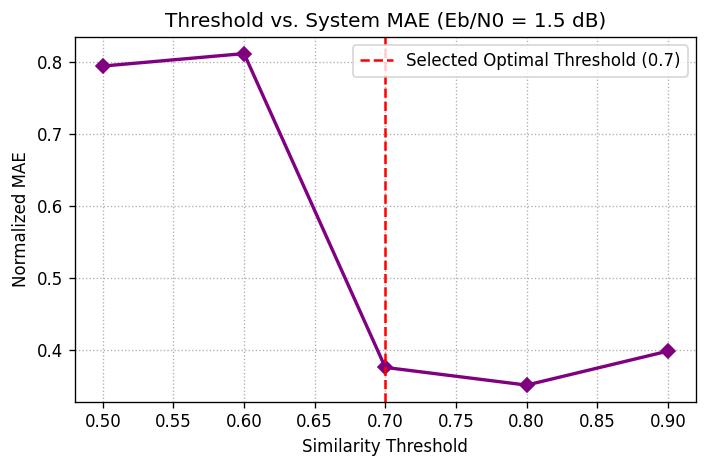


開始執行端到端 6G 語意通訊 JSON 測試管線 (包含消融對照)...

正在產生 Eb/N0 = [1.0, 2.0, 3.0, 4.0, 5.0] 的 BPSK 波形對比圖


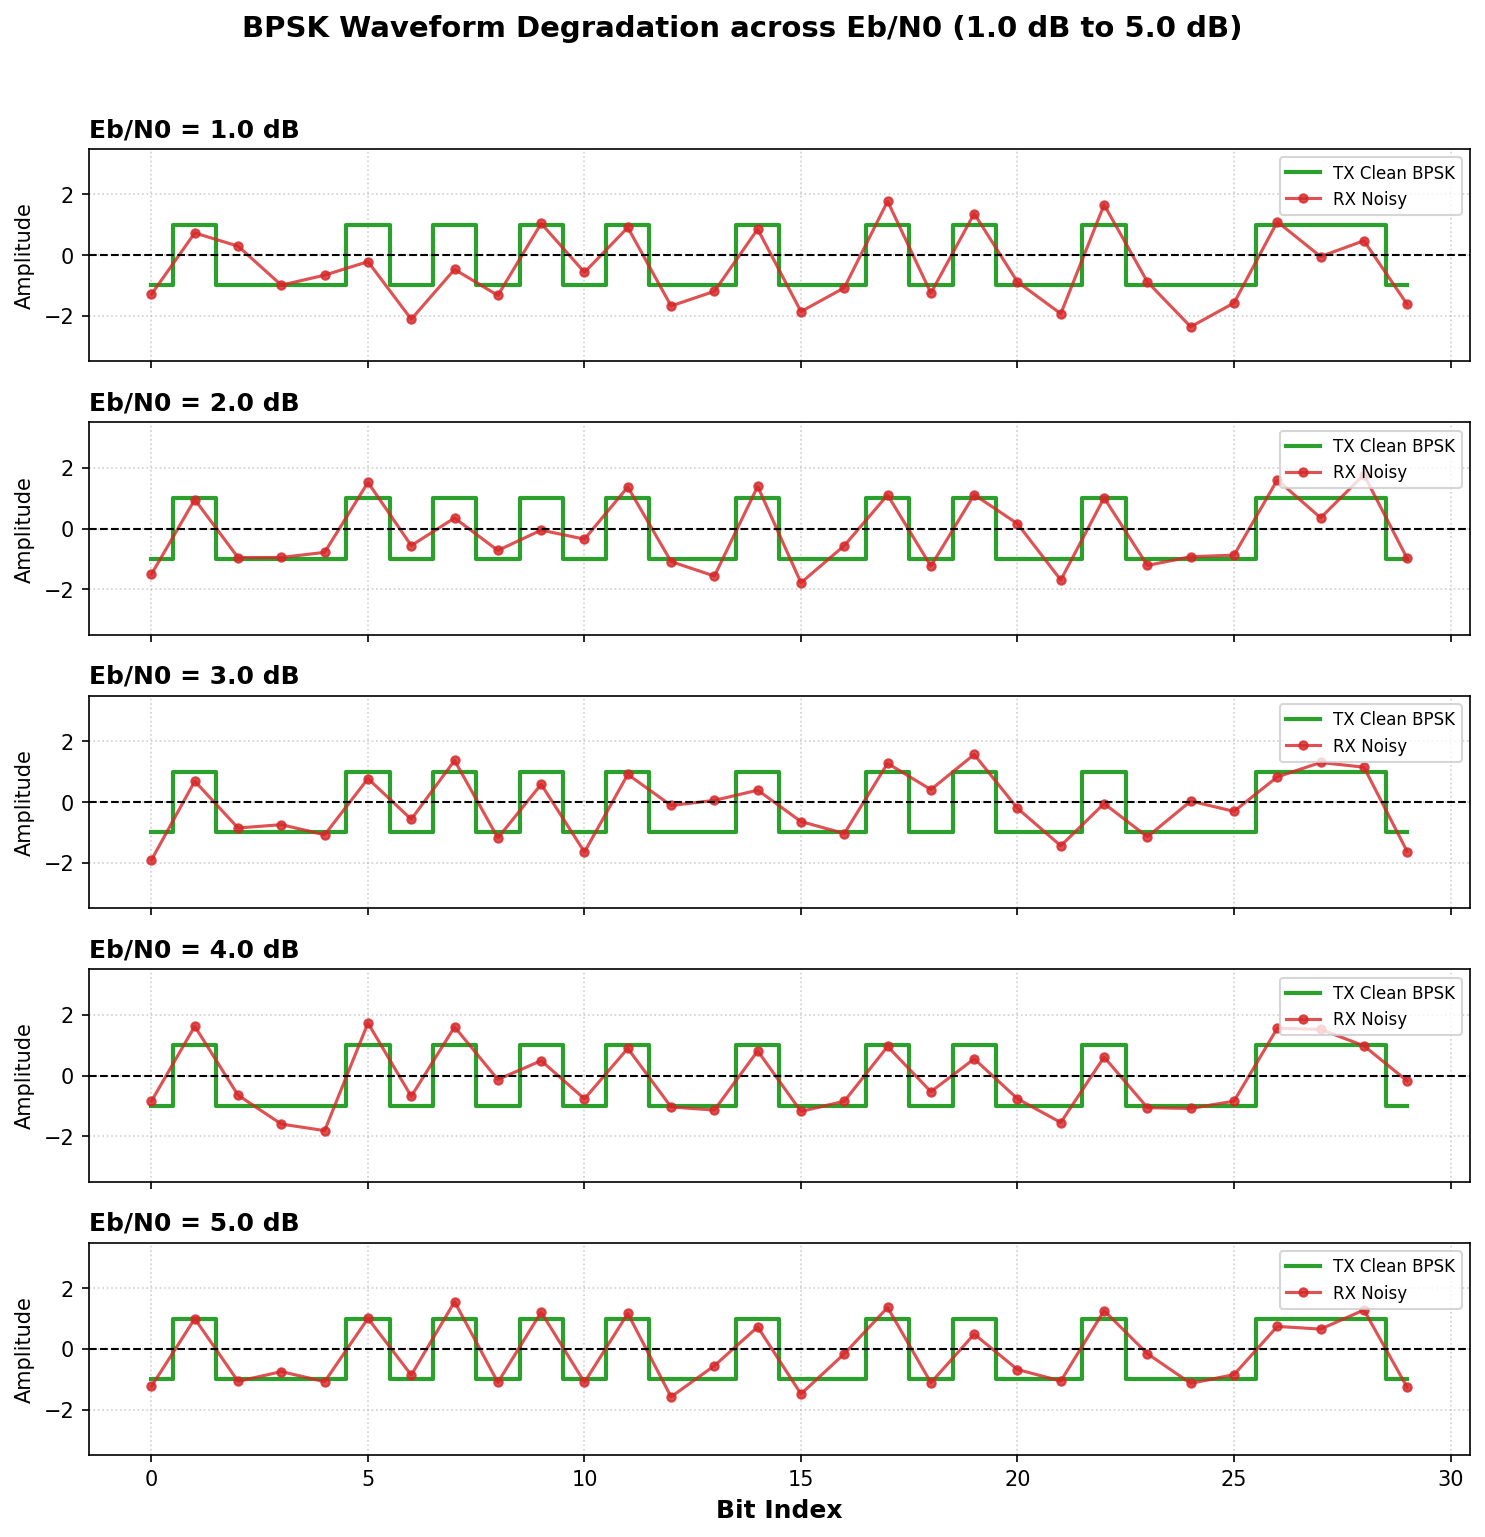


【測試環境】Eb/N0 = 1.0 dB
 [ 異常失誤] 發現高誤差樣本！ (Eb/N0 = 1.0 dB)
 -> 1. 原始正確發射: ERR: Fuel_pressure 19.51
 -> 2. 接收端收到雜訊: ERR:,?U%l_p?ersure 19n51? nineteen po+nt?fkve ome
 -> 3. LLM 實際輸出: {'status': 'ERR', 'sensor': 'Furnace_Temp_K', 'value': 1195}
 -> 相對誤差 : 1.0000 | 感測器命中: 失敗 (誤判) | JSON 格式: 正常
----------------------------------------
 [ 異常失誤] 發現高誤差樣本！ (Eb/N0 = 1.0 dB)
 -> 1. 原始正確發射: ERR: Fuel_pressure 15.74
 -> 2. 接收端收到雜訊: ?RR: DUedVpr%ssQpe 15//5!(fiftFen?poiot$?ev%n fou?)
 -> 3. LLM 實際輸出: {'status': 'ERR', 'sensor': 'Coolant_temp', 'value': 51.74}
 -> 相對誤差 : 1.0000 | 感測器命中: 失敗 (誤判) | JSON 格式: 正常
----------------------------------------
 [ 異常失誤] 發現高誤差樣本！ (Eb/N0 = 1.0 dB)
 -> 1. 原始正確發射: ERR: Engine_rpm 382.0
 -> 2. 接收端收到雜訊: ERR: ?ngi?e_rpm 38p?0 (thvee hqldr-d ANd %ichty?twO)
 -> 3. LLM 實際輸出: {'status': 'ERR', 'sensor': 'Engine_rpm', 'value': 3820}
 -> 相對誤差 : 1.0000 | 感測器命中: 成功 | JSON 格式: 正常
----------------------------------------
 [ 異常失誤] 發現高誤差樣本！ (Eb/N0 = 1.0 dB)
 -> 1. 原始正確發射: ERR: Lub_

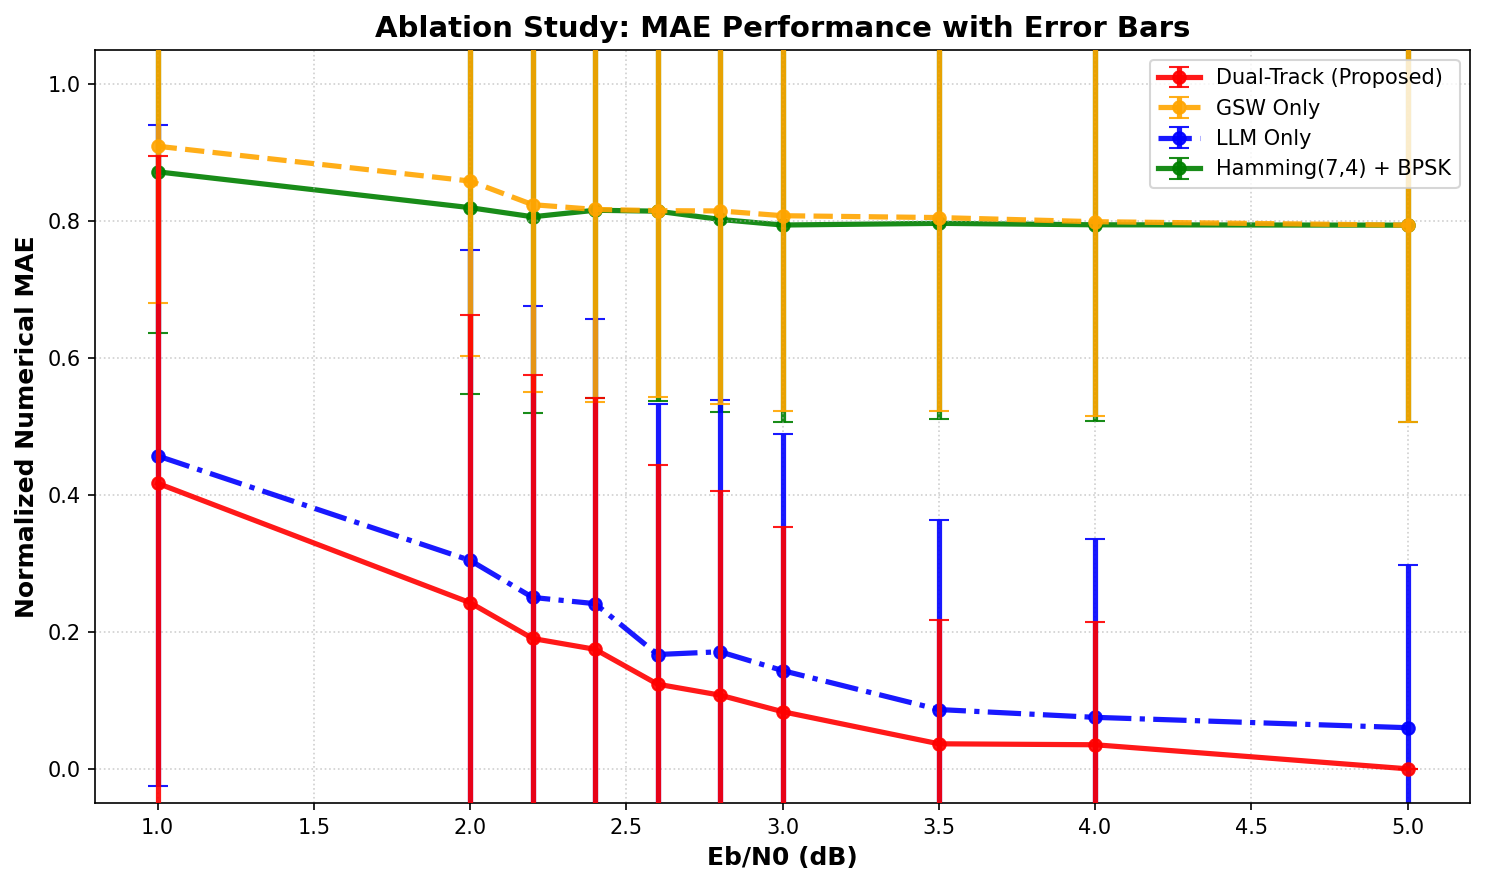

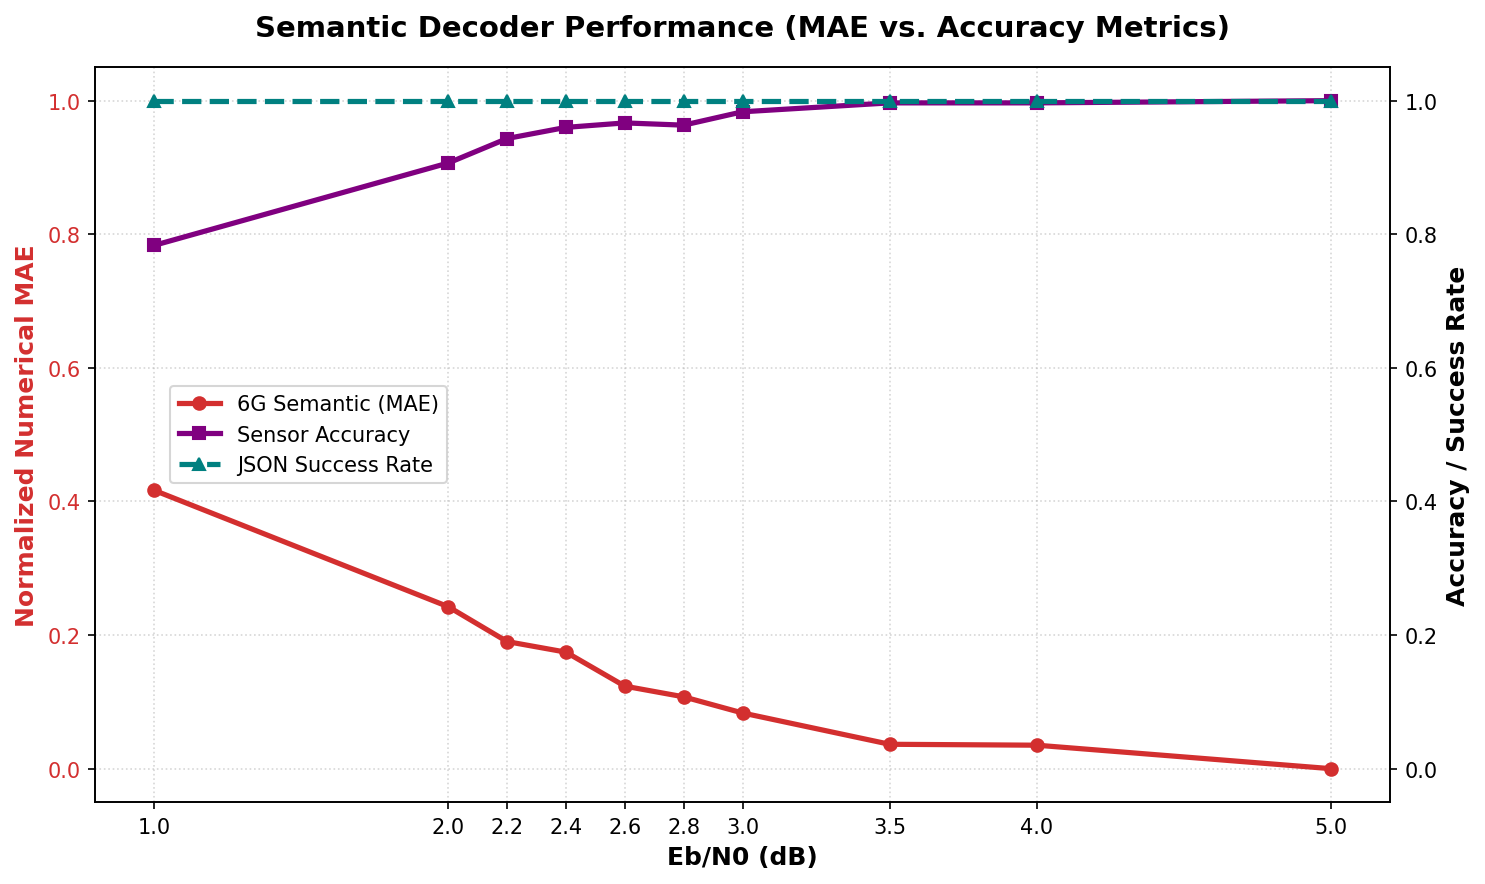


程式執行完畢！所有圖表與終端機 Log 皆已更新！


In [2]:
#final
import os
import json
import re
import random
import textwrap
import pandas as pd
import ollama
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from num2words import num2words
import difflib
import time
import subprocess
import urllib.request
from scipy.special import erfc

# 引入 BERTScorer 與強制靜音模組
import transformers
import logging
transformers.logging.set_verbosity_error()
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
from bert_score import BERTScorer
from datetime import datetime


# 固定隨機種子，確保實驗具備可重現性並消除非單調誤差

np.random.seed(42)
random.seed(42)


# 0. 理論等效 BER 計算

print("="*70)
print("【通道環境對照】AWGN BPSK 理論等效 BER (與 BSC 訓練集比對)")
print("="*70)
for ebno_db in [1.0, 2.0, 3.0, 4.0, 5.0]:
    ebno_linear = 10 ** (ebno_db / 10.0)
    ber_theoretical = 0.5 * erfc(np.sqrt(ebno_linear))
    print(f" Eb/N0 = {ebno_db:.1f} dB  -->  等效 BER = {ber_theoretical:.5f}")


# =====================================================================
# 1. 系統初始化：載入資料集與無監督邊界計算
# =====================================================================
print("系統初始化：載入外部資料集與計算動態邊界...")

dataset_id = "MohammedSohail/predictive-maintenance-dataset"
#dataset_id = "DarkNeuronAI/water-potability-3k"
dataset = load_dataset(dataset_id, split="train")
df = dataset.to_pandas()

print("正在自動掃描數值特徵...")
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()

features = []
for col in numerical_columns:
    if not any(keyword in col.lower() for keyword in ['id', 'condition', 'status', 'label', 'class']):
        prompt_key = col.replace(" ", "_")
        features.append((prompt_key, col))

bounds_dict = {}
for prompt_key, df_column in features:
    normal_min = round(df[df_column].quantile(0.05), 2)
    normal_max = round(df[df_column].quantile(0.95), 2)
    bounds_dict[prompt_key] = (normal_min, normal_max)

print(f"\n=== 已動態載入 {len(features)} 個感測器特徵，標準安全邊界 (5% ~ 95%) ===")
for sensor, (min_val, max_val) in bounds_dict.items():
    print(f"{sensor:<25}: {min_val:>8} ~ {max_val:<8}")
print("=====================================\n")

anomaly_records = []
for index, row in df.iterrows():
    is_anomaly = False
    for prompt_key, df_column in features:
        val = row[df_column]
        if pd.isna(val):
            continue
        min_val, max_val = bounds_dict[prompt_key]
        if val < min_val or val > max_val:
            is_anomaly = True
            break
    if is_anomaly:
        anomaly_records.append(row.to_dict())

        if len(anomaly_records) == 100:
            break

print(f"成功透過無監督邊界過濾出 {len(anomaly_records)} 筆異常測試資料！\n")

# =====================================================================
# 2. 核心模組定義 (Tx / Channel / Rx / Metrics)
# =====================================================================
def my_encoder(json_data):
    faulty_sensors = {}
    max_risk = -1
    riskiest_sensor = None
    riskiest_val = None

    for key, value in json_data.items():
        min_val, max_val = bounds_dict[key]
        if value < min_val or value > max_val:
            faulty_sensors[key] = value

        center = (min_val + max_val) / 2
        span = (max_val - min_val) / 2
        risk = abs(value - center) / span if span != 0 else 0

        if risk > max_risk:
            max_risk = risk
            riskiest_sensor = key
            riskiest_val = value

    if not faulty_sensors:
        faulty_sensors[riskiest_sensor] = riskiest_val

    base_sentence = f"ERR: {riskiest_sensor} {faulty_sensors.get(riskiest_sensor, riskiest_val)}"

    def replace_with_redundancy(match):
        num_str = match.group(0)
        num = float(num_str) if '.' in num_str else int(num_str)
        english_words = num2words(num).replace("-", " ")
        return f"{num} ({english_words})"

    final_signal = re.sub(r'[-+]?\d+(?:\.\d+)?', replace_with_redundancy, base_sentence)
    return base_sentence, final_signal

def hamming_74_encode(bits):
    pad_len = (4 - len(bits) % 4) % 4
    bits_padded = np.pad(bits, (0, pad_len))
    G = np.array([[1,0,0,0, 1,1,0], [0,1,0,0, 1,0,1], [0,0,1,0, 0,1,1], [0,0,0,1, 1,1,1]])
    return (bits_padded.reshape(-1, 4).dot(G) % 2).flatten(), pad_len

def hamming_74_decode(bits, pad_len):
    H = np.array([[1,1,0,1,1,0,0], [1,0,1,1,0,1,0], [0,1,1,1,0,0,1]])
    reshaped = bits.reshape(-1, 7)
    syndromes = reshaped.dot(H.T) % 2
    syn_map = {6:0, 5:1, 3:2, 7:3, 4:4, 2:5, 1:6}
    for i, syn in enumerate(syndromes):
        val = syn[0]*4 + syn[1]*2 + syn[2]*1
        if val in syn_map: reshaped[i, syn_map[val]] ^= 1
    decoded = reshaped[:, :4].flatten()
    return decoded[:-pad_len] if pad_len > 0 else decoded

def awgn_bpsk_channel(text, ebno_db, use_hamming=False):
    byte_data = text.encode('utf-8')
    bits = np.unpackbits(np.frombuffer(byte_data, dtype=np.uint8)).astype(int)
    pad_len = 0
    if use_hamming:
        bits, pad_len = hamming_74_encode(bits)

    tx_symbols = 2 * bits - 1
    ebno_linear = 10 ** (ebno_db / 10.0)
    R = 4/7 if use_hamming else 1.0
    noise_std = np.sqrt(1.0 / (2.0 * R * ebno_linear))
    noise = np.random.normal(0, noise_std, len(tx_symbols))
    rx_bits = ((tx_symbols + noise) > 0).astype(int)

    if use_hamming:
        rx_bits = hamming_74_decode(rx_bits, pad_len)

    chars = []
    for i in range(0, len(rx_bits), 8):
        byte_chunk = rx_bits[i:i+8]
        if len(byte_chunk) == 8:
            byte_val = int(''.join(map(str, byte_chunk)), 2)
            chars.append(chr(byte_val) if 32 <= byte_val <= 126 or byte_val in (10, 13) else '?')
    return ''.join(chars)

def plot_multi_bpsk_waveforms(text, ebno_list=[1.0, 2.0, 3.0, 4.0, 5.0], num_bits=30):
    print(f"\n正在產生 Eb/N0 = {ebno_list} 的 BPSK 波形對比圖")
    byte_data = text.encode('utf-8')
    bits = np.unpackbits(np.frombuffer(byte_data, dtype=np.uint8)).astype(int)[:num_bits]

    tx_symbols = 2 * bits - 1
    x = np.arange(len(tx_symbols))
    fig, axes = plt.subplots(len(ebno_list), 1, figsize=(10, 2 * len(ebno_list)), sharex=True, dpi=150)
    if len(ebno_list) == 1: axes = [axes]

    for ax, ebno_db in zip(axes, ebno_list):
        ebno_linear = 10 ** (ebno_db / 10.0)
        noise_std = np.sqrt(1.0 / (2.0 * ebno_linear))
        noise = np.random.normal(0, noise_std, len(tx_symbols))
        rx_symbols = tx_symbols + noise
        ax.step(x, tx_symbols, where='mid', label='TX Clean BPSK', color='#2ca02c', linewidth=2)
        ax.plot(x, rx_symbols, marker='o', markersize=4, linestyle='-', label=f'RX Noisy', color='#d62728', alpha=0.8)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(f'Eb/N0 = {ebno_db} dB', fontsize=12, fontweight='bold', loc='left')
        ax.set_ylabel('Amplitude')
        ax.set_ylim(-3.5, 3.5)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel('Bit Index', fontsize=12, fontweight='bold')
    plt.suptitle('BPSK Waveform Degradation across Eb/N0 (1.0 dB to 5.0 dB)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def ensure_ollama_running():
    try: urllib.request.urlopen("http://127.0.0.1:11434/", timeout=1)
    except Exception:
        print("\n 偵測到 Ollama 伺服器已休眠或斷線，正在自動重新喚醒...")
        subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        time.sleep(5)

# 記憶體快取
llm_cache = {}

def decode_signal(input_text):
    if input_text in llm_cache: return llm_cache[input_text]

    sensor_bullets = "\n".join([f"- {s}" for s in bounds_dict.keys()])
    instruction = f"""You are an Industrial Data Extractor.
Extract the sensor data from the corrupted log into a JSON object.

CRITICAL RULES:
1. EXACT MATCH: Sensor names MUST exactly match the list below. Do NOT append units.
{sensor_bullets}
2. DECIMAL RECOVERY: The log contains digits followed by its English spelling in parentheses. If the digits or decimal dots are corrupted (e.g., missing or turned into '?' or letters), YOU MUST READ THE ENGLISH WORDS (e.g., "point", "poi?t", "zgro") to place the decimal dot correctly!"""

    formatted_prompt = textwrap.dedent(f"""\
    Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

    ### Instruction:
    {instruction}

    ### Input:
    {input_text}

    ### Response:
    """)

    max_retries = 2
    for attempt in range(max_retries):
        try:
            response = ollama.generate(
                model='semantic-decoder',
                prompt=formatted_prompt,
                format='json',
                raw=True,
                options={'temperature': 0.0, 'stop': ['###', '<|eot_id|>']}
            )
            result = response['response'].strip()
            llm_cache[input_text] = result
            return result
        except Exception as e:
            ensure_ollama_running()
            if attempt < max_retries - 1:
                print(f"🔄 正在進行第 {attempt + 1} 次推論重試...")
                continue
            print(f"\n [錯誤] Ollama 呼叫失敗: {e}")
            return "{}"
    return "{}"

def extract_json_from_text(text):
    try:
        clean_text = text.replace("'", '"').replace("”", '"').replace("“", '"')
        match = re.search(r'\{.*?\}', clean_text.replace('\n', ''))
        if match:
            return json.loads(match.group(0))
        return json.loads(clean_text)
    except:
        return {"status": "FAILED", "sensor": "Decode_Failed", "value": -1}

def calculate_numerical_mae(ground_truth_dict, parsed_json, rx_received="", mode="dual", threshold=0.70):
    valid_sensors = list(bounds_dict.keys())
    matched_true_key = None

    if rx_received:
        rx_clean = re.sub(r'[^a-z]', '', rx_received.lower())
        global_best_ratio = 0.0
        global_best_sensor = None

        for valid_s in valid_sensors:
            valid_clean = re.sub(r'[^a-z]', '', valid_s.lower())
            window_size = len(valid_clean)
            for i in range(len(rx_clean) - window_size + 1):
                window_str = rx_clean[i : i + window_size]
                ratio = difflib.SequenceMatcher(None, window_str, valid_clean).ratio()
                if ratio > global_best_ratio:
                    global_best_ratio = ratio
                    global_best_sensor = valid_s

        if mode == "dual":
            if global_best_ratio >= threshold: matched_true_key = global_best_sensor
        elif mode == "gsw_only":
            if global_best_ratio >= threshold: matched_true_key = global_best_sensor
            else: parsed_json = {"sensor": "Threshold_Failed", "value": -1}
        elif mode == "llm_only": pass
        elif mode == "hamming": matched_true_key = global_best_sensor

    if not matched_true_key and mode in ["dual", "llm_only"]:
        pred_sensor = str(parsed_json.get("sensor", "")).lower()
        valid_sensors_lower = [k.lower() for k in valid_sensors]
        closest_matches = difflib.get_close_matches(pred_sensor, valid_sensors_lower, n=1, cutoff=0.6)
        if closest_matches:
            matched_true_key = next(k for k in valid_sensors if k.lower() == closest_matches[0])

    raw_val = parsed_json.get("value", -1)
    true_target_sensor = list(ground_truth_dict.keys())[0]
    true_target_value = ground_truth_dict[true_target_sensor]

    sensor_acc = 1 if matched_true_key == true_target_sensor else 0
    json_succ = 1 if str(parsed_json.get("sensor")) not in ["Decode_Failed", "Threshold_Failed", ""] else 0

    if matched_true_key and matched_true_key in ground_truth_dict:
        true_value = ground_truth_dict[matched_true_key]
        if pd.isna(true_value): return 1.0, sensor_acc, json_succ
        try:
            val_str = str(raw_val).replace(",", "")
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", val_str)
            if nums:
                pred_value = float(nums[0])
                relative_error = abs(true_value - pred_value) / (abs(true_value) + 1e-5)
                return min(relative_error, 1.0), sensor_acc, json_succ
        except ValueError: pass
    return 1.0, sensor_acc, json_succ

print("\n初始化：正在載入 BERTScore 評估模型")
bert_scorer = BERTScorer(lang="en")

def calculate_bert_score(ref_text, cand_text):
    P, R, F1 = bert_scorer.score([cand_text], [ref_text])
    return F1.item()

# =====================================================================
# 3. Tx 發射前樣本邊界比對與驗證
# =====================================================================
print("="*70)
print("【預檢步驟】驗證測試樣本並準備發射資料")
print("="*70)

verified_anomaly_data = []

for idx, raw_row in enumerate(anomaly_records):
    current_data = {}
    for prompt_key, df_column in features:
        val = raw_row.get(df_column)
        if val is not None and not pd.isna(val):
            current_data[prompt_key] = round(float(val), 2)

    base_truth_str, tx_signal_with_redundancy = my_encoder(current_data)
    parts = base_truth_str.split(" ")
    if len(parts) >= 3:
        try:
            final_sensor = parts[1]
            final_val = float(parts[2])
            verified_anomaly_data.append(({final_sensor: final_val}, base_truth_str, tx_signal_with_redundancy))
        except ValueError: pass

print(f"成功準備 {len(verified_anomaly_data)} 筆異常測試資料！\n")

# =====================================================================
# 4. 門檻值掃描實驗
# =====================================================================
print("\n" + "="*70)
print("全域滑動視窗門檻值最佳化掃描 (Eb/N0 = 1.5 dB)")
print("="*70)
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
thresh_maes = []

for th in thresholds:
    temp_maes = []
    for current_data, base_str, tx_sig in verified_anomaly_data:
        rx = awgn_bpsk_channel(tx_sig, 1.5)
        raw_llm_output = decode_signal(rx) if th >= 0.7 else ""
        parsed_json = extract_json_from_text(raw_llm_output) if raw_llm_output else {}
        err, _, _ = calculate_numerical_mae(current_data, parsed_json, rx, mode="dual", threshold=th)
        temp_maes.append(err)
    thresh_maes.append(np.mean(temp_maes))
    print(f" 門檻值 = {th:.1f} | 系統 MAE = {thresh_maes[-1]:.4f}")

plt.figure(figsize=(6,4), dpi=120)
plt.plot(thresholds, thresh_maes, marker='D', color='purple', linewidth=2)
plt.axvline(x=0.7, color='red', linestyle='--', label='Selected Optimal Threshold (0.7)')
plt.title("Threshold vs. System MAE (Eb/N0 = 1.5 dB)")
plt.xlabel("Similarity Threshold")
plt.ylabel("Normalized MAE")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# =========================================================================
# 5. 自動化測試管線主迴圈
# =========================================================================
ebno_sweep = [1.0, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.5, 4.0, 5.0]
modes = ["dual", "gsw_only", "llm_only", "hamming"]
num_trials = 3

results_db = {m: {"mae_mean": [], "mae_std": [], "sensor_acc": [], "json_acc": [], "bert_mean": []} for m in modes}
detailed_logs = []
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
dataset_name = dataset_id.split("/")[-1] if "/" in dataset_id else dataset_id

print("\n" + "="*70)
print("開始執行端到端 6G 語意通訊 JSON 測試管線 (包含消融對照)...")
print("="*70)

if verified_anomaly_data:
    demo_tx_signal = verified_anomaly_data[0][2]
    plot_multi_bpsk_waveforms(demo_tx_signal, ebno_list=[1.0, 2.0, 3.0, 4.0, 5.0])

for ebno in ebno_sweep:
    print(f"\n【測試環境】Eb/N0 = {ebno} dB")
    temp_metrics = {m: {"mae": [], "s_acc": [], "j_acc": [], "bert": []} for m in modes}

    for trial in range(num_trials):
        for gt_tuple, base_truth_str, tx_signal in verified_anomaly_data:
            rx_standard = awgn_bpsk_channel(tx_signal, ebno, use_hamming=False)
            rx_hamming = awgn_bpsk_channel(base_truth_str, ebno, use_hamming=True)

            for mode in modes:
                rx_in = rx_hamming if mode == "hamming" else rx_standard

                if mode in ["dual", "llm_only"]:
                    raw_llm_output = decode_signal(rx_in)
                    parsed_json = extract_json_from_text(raw_llm_output)
                else:
                    parsed_json = {}

                err, s_acc, j_acc = calculate_numerical_mae(gt_tuple, parsed_json, rx_in, mode=mode, threshold=0.70)
                temp_metrics[mode]["mae"].append(err)
                temp_metrics[mode]["s_acc"].append(s_acc)
                temp_metrics[mode]["j_acc"].append(j_acc)

                if mode == "dual":
                    # 計算 BERTScore
                    reconstructed_str = f"ERR: {parsed_json.get('sensor', 'Unknown')} {parsed_json.get('value', 'Unknown')}"
                    try: temp_metrics[mode]["bert"].append(calculate_bert_score(base_truth_str, reconstructed_str))
                    except Exception: temp_metrics[mode]["bert"].append(0.0)


                    if trial == 0 and err > 0.1:
                        print(f" [ 異常失誤] 發現高誤差樣本！ (Eb/N0 = {ebno} dB)")
                        print(f" -> 1. 原始正確發射: {base_truth_str}")
                        print(f" -> 2. 接收端收到雜訊: {rx_in}")
                        print(f" -> 3. LLM 實際輸出: {parsed_json}")
                        sensor_status = "成功" if s_acc == 1 else "失敗 (誤判)"
                        json_status = "正常" if j_acc == 1 else "崩潰"
                        print(f" -> 相對誤差 : {err:.4f} | 感測器命中: {sensor_status} | JSON 格式: {json_status}")
                        print("-" * 40)

                        detailed_logs.append({
                            "Timestamp": current_time, "Dataset": dataset_name, "Eb/N0 (dB)": ebno,
                            "Original_TX": base_truth_str, "Noisy_RX": rx_in,
                            "Decoded_JSON": json.dumps(parsed_json, ensure_ascii=False),
                            "MAE": round(err, 4), "BERTScore": round(temp_metrics[mode]["bert"][-1], 4)
                        })


    for mode in modes:
        results_db[mode]["mae_mean"].append(np.mean(temp_metrics[mode]["mae"]))
        results_db[mode]["mae_std"].append(np.std(temp_metrics[mode]["mae"]))
        results_db[mode]["sensor_acc"].append(np.mean(temp_metrics[mode]["s_acc"]))
        results_db[mode]["json_acc"].append(np.mean(temp_metrics[mode]["j_acc"]))
        if mode == "dual":
            results_db[mode]["bert_mean"].append(np.mean(temp_metrics[mode]["bert"]))

# =========================================================================
# 6. 列印最終數據結果報表與繪圖
# =========================================================================
print("\n" + "="*70)
print("測試結果總表與 CSV 儲存")
print("="*70)

summary_df = pd.DataFrame({
    "Eb/N0 (dB)": ebno_sweep,
    "Dual MAE": results_db["dual"]["mae_mean"],
    "GSW MAE": results_db["gsw_only"]["mae_mean"],
    "LLM MAE": results_db["llm_only"]["mae_mean"],
    "Hamming MAE": results_db["hamming"]["mae_mean"],
    "Dual BERT F1": results_db["dual"]["bert_mean"],
    "Dual Sensor Acc": results_db["dual"]["sensor_acc"],
    "Dual JSON Acc": results_db["dual"]["json_acc"]
})
print(summary_df.to_string(index=False))

summary_csv_path = "/content/drive/MyDrive/6G_Semantic_Ablation_Summary.csv"
detailed_csv_path = "/content/drive/MyDrive/6G_Semantic_Ablation_Detailed.csv"

try:
    file_exists_sum = os.path.isfile(summary_csv_path)
    summary_df.to_csv(summary_csv_path, mode='a', header=not file_exists_sum, index=False, encoding='utf-8-sig')
    pd.DataFrame(detailed_logs).to_csv(detailed_csv_path, mode='a', header=not os.path.isfile(detailed_csv_path), index=False, encoding='utf-8-sig')
    print(f"\n 平均總表已儲存至：{summary_csv_path}")
    print(f" 每筆詳細紀錄已儲存至：{detailed_csv_path}\n")
except Exception as e:
    print(f" CSV 存檔失敗：{e}\n")

line_styles = {"dual": "-", "gsw_only": "--", "llm_only": "-.", "hamming": "-"}
z_orders = {"dual": 4, "gsw_only": 3, "llm_only": 2, "hamming": 1}

#消融實驗與誤差棒
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)
colors = {"dual": "red", "gsw_only": "orange", "llm_only": "blue", "hamming": "green"}
labels = {"dual": "Dual-Track (Proposed)", "gsw_only": "GSW Only", "llm_only": "LLM Only", "hamming": "Hamming(7,4) + BPSK"}

for mode in modes:
    ax1.errorbar(ebno_sweep, results_db[mode]["mae_mean"], yerr=results_db[mode]["mae_std"],
                 color=colors[mode], label=labels[mode], marker='o',
                 linestyle=line_styles[mode], zorder=z_orders[mode],
                 capsize=5, linewidth=2.5, alpha=0.9)

ax1.set_xlabel("Eb/N0 (dB)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Normalized Numerical MAE", fontsize=12, fontweight='bold')
ax1.set_title("Ablation Study: MAE Performance with Error Bars", fontsize=14, fontweight='bold')
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc="upper right")
plt.tight_layout()
try: plt.savefig("/content/drive/MyDrive/6G_Ablation_MAE.png")
except: pass
plt.show()

# 重新設計的 圖 B：MAE 與 鑑別度指標的「黃金交叉圖」 (加入 JSON 成功率)
fig, ax3 = plt.subplots(figsize=(10, 6), dpi=150)
color_mae = '#D32F2F'
ax3.set_xlabel('Eb/N0 (dB)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Normalized Numerical MAE', color=color_mae, fontsize=12, fontweight='bold')
line1 = ax3.plot(ebno_sweep, results_db["dual"]["mae_mean"], color=color_mae, marker='o', linestyle='-', linewidth=2.5, label='6G Semantic (MAE)')
ax3.set_ylim(-0.05, 1.05)
ax3.tick_params(axis='y', labelcolor=color_mae)
ax3.grid(True, which="both", linestyle=':', alpha=0.5)

# 右軸換成 Accuracy / Success Rate，並同時繪製兩條線
ax4 = ax3.twinx()
color_acc = '#800080' # 紫色 (Sensor)
color_json = '#008080' # 藍綠色 (JSON)
ax4.set_ylabel('Accuracy / Success Rate', color='black', fontsize=12, fontweight='bold')

line2 = ax4.plot(ebno_sweep, results_db["dual"]["sensor_acc"], color=color_acc, marker='s', linestyle='-', linewidth=2.5, label='Sensor Accuracy')
line3 = ax4.plot(ebno_sweep, results_db["dual"]["json_acc"], color=color_json, marker='^', linestyle='--', linewidth=2.5, label='JSON Success Rate')

ax4.set_ylim(-0.05, 1.05)
ax4.tick_params(axis='y', labelcolor='black')

# 合併圖例
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='center left', bbox_to_anchor=(0.05, 0.5), fontsize=10, frameon=True)
plt.title('Semantic Decoder Performance (MAE vs. Accuracy Metrics)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(ebno_sweep)
plt.tight_layout()
try: plt.savefig("/content/drive/MyDrive/6G_Original_Metrics_Cross.png")
except: pass
plt.show()

print("\n程式執行完畢！所有圖表與終端機 Log 皆已更新！")